# Overview

**Multi-Agent Hierarchical Pipeline**

This notebook implements a **hierarchical, multi-agent fusion pipeline** for the Fake News Detection project.

Here the pipeline is framed as a **forensic investigation**:  
Each agent plays the role of a **forensic expert** (vision, text, context), and a supervising **Judge** agent reads their reports to decide whether a news item is more likely *real* or *fake*.

Instead of a single agent calling all tools, **LangGraph** is used to coordinate several specialized forensic agents (vision, text, and context) plus a supervising **Judge** agent that fuses their reports into a final verdict.

The goal of this notebook is to:
- Transform the previous **single-agent fusion** setup into a **multi-agent architecture** with clearer roles and reports.
- Compare **local** decisions (per-agent pre/post tool use) with the **global** decision of the Judge.
- Study how the Judge uses conflicting or agreeing forensic reports to revise its initial impression of the news item.
- Keep the **tool stack and dataset** very similar to the single-agent pipeline, so differences mainly reflect architecture (single vs multi-agent), not data or models.

This pipeline has **two levels of reasoning**:

1. **Local Forensic Agents (Specialists)**  
   Each agent follows a 3-phase protocol — *Intuition → Forensics → Synthesis* — and produces its own verdict + narrative report:
   - **Vision Agent (Graphics Forensics)**  
     - Sees the **image** directly.  
     - Uses a vision toolkit (CLIP zero-shot + visual concepts) to get a tentative *Real/Fake* label and salient concepts.  
     - Writes a short report explaining how the tools support or challenge its initial impression.
   - **Text Agent (Linguistic Forensics)**  
     - Reads the **headline only**.  
     - Uses RoBERTa pretrained on Fakeddit (`yaoyinnan/roberta-fakeddit`) plus **VADER** sentiment to classify the headline as *Real/Fake* and estimate how sensational it is.  
     - Produces its own pre- and post-tool decision and a short explanation.
   - **Context Agent (Context / Alignment Forensics)**  
     - Sees **image + headline + BLIP-2 caption**.  
     - Uses **MPNet** (headline–caption semantic similarity) and **CLIP** (image–headline alignment) to judge whether the overall context is **Aligned**, **Generic**, or **Mismatch**.  
     - Explains how well the modalities agree and how strong that evidence is.

2. **Global Judge Agent (Supervisor)**  
   Judge agent follows a 3-phase protocol — *Intuition → Forensics → Synthesis* — and produces its own verdict + narrative report:
   - Sees the **image + headline** and reads the three forensic reports (vision, text, context).  
   - Forms an **initial impression** (*Real/Fake*), then revises it after considering the experts’ reports.  
   - Outputs:
     - Initial vs final decision (*Real/Fake*),  
     - Whether it changed its mind,  
     - Which report influenced the verdict the most (Vision/Text/Context/Own Gut),  
     - A **confidence level** (High/Medium/Low),  
     - A user-facing explanation and a **nudge** (how to think critically about similar content).

---

**What this notebook does**

- Load the **Fakeddit** subset (headlines, BLIP-2 captions, local image paths, labels).
- Load and initialize all models:
  - **CLIP** for vision and cross-modal similarity,
  - **RoBERTa (yaoyinnan/roberta-fakeddit)** for headline classification,
  - **SentenceTransformer (all-mpnet-base-v2)** for text–text similarity,
  - **VADER** for sentiment analysis.
- Define three **forensic tools** (vision, text, context) and run them inside LangGraph nodes.
- Build a **LangGraph StateGraph** with four nodes:
  - `vision_agent → text_agent → context_agent → judge_agent`.
- Run the graph on a batch of Fakeddit samples, collecting:
  - Pre/post decisions for each agent (Vision, Text, Judge),
  - Their narrative reports and confidences,
  - The final Judge verdict.
- Compute and display:
  - **Accuracies** and **confusion matrices** for each agent (pre vs post),
  - High-level observations about how multi-agent fusion compares to:
    - The **blind single-agent fusion pipeline**, and
    - The **vision-enabled single-agent fusion pipeline**.

This notebook is the first **LangGraph-based multi-agent extension** of the project and will serve as a bridge between the earlier single-agent fusion baselines and future, more complex agentic systems (e.g., with routing, tool-selection policies, or interactive UIs).


# Setup

Install dependencies, clone the repo, and import required libraries and modules.

In [1]:
# Install dependencies
!pip install -q langgraph langchain_openai vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 477.4/477.4 kB 16.7 MB/s eta 0:00:00


In [2]:
# Clone the project repo
!git clone https://github.com/gizayceylan/FakeNews.git

# Add it to Python path
import sys
sys.path.append("/content/FakeNews")


Cloning into 'FakeNews'...
remote: Enumerating objects: 191, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 191 (delta 9), reused 6 (delta 3), pack-reused 171 (from 1)
Receiving objects: 100% (191/191), 18.95 MiB | 24.94 MiB/s, done.
Resolving deltas: 100% (97/97), done.


In [3]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import json
import base64

from tqdm import tqdm
from PIL import Image
from numpy.linalg import norm
from typing import Optional, Dict, Any
from typing_extensions import TypedDict

# ML/DL libraries
from transformers import CLIPProcessor, CLIPModel
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer, util
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import confusion_matrix, classification_report

# LangChain, LangGraph
from langchain.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END

# Import custom utility for OpenAI Client
from utils.api_key import load_openai_client

In [4]:
# Set OpenAI API
client = load_openai_client()

# Data

Load the Fakeddit metadata, clean it, and select the subset of samples containing valid image URLs.

In [5]:
# Unzip fakeddit_images.zip from /content/FakeNews/assets/content/master_pipeline_assets/
!unzip -q /content/FakeNews/assets/fakeddit_images.zip -d /content/FakeNews/assets

In [6]:
# Load the pre-processed metadata
subset_path = "/content/FakeNews/assets/fakeddit_subset_blip2captions.csv"
image_df = pd.read_csv(subset_path)

# Define the path for the image directory (which was unzipped)
img_dir = "/content/FakeNews/assets/content/fakeddit_images"

# Update the DataFrame paths to reflect the new location
image_df['image_path'] = image_df['image_path'].apply(
    lambda p: os.path.join(img_dir, os.path.basename(p))
)

print(f"Loaded {len(image_df)} clean samples.")
print("Shape subset:", image_df.shape)
image_df.head()


Loaded 225 clean samples.
Shape subset: (225, 5)


,image_path,clean_title,label,image_url,blip2_caption
0,/content/FakeNews/assets/content/fakeddit_imag...,this tiny spoiler on this car,1,https://preview.redd.it/r05zlwu9ceo31.jpg?widt...,the back end of a black audi parked at a gas s...
1,/content/FakeNews/assets/content/fakeddit_imag...,i am going to a hospital in due to notoriety o...,0,https://external-preview.redd.it/WYnfGnWhlS17K...,a man in white clothes is surrounded by police...
2,/content/FakeNews/assets/content/fakeddit_imag...,flamingo bros where are my shoes,0,https://preview.redd.it/2bvyzw2ou2tz.jpg?width...,a woman sitting in a chair with the words flam...
3,/content/FakeNews/assets/content/fakeddit_imag...,people really did buy poop on black friday,1,https://external-preview.redd.it/QupwrX2NA0Tzo...,a brown box with a black face on it
4,/content/FakeNews/assets/content/fakeddit_imag...,chips and salsa worth stolen from exeter stora...,1,https://external-preview.redd.it/6ZR075IHnrgw1...,lays chips are in a display case


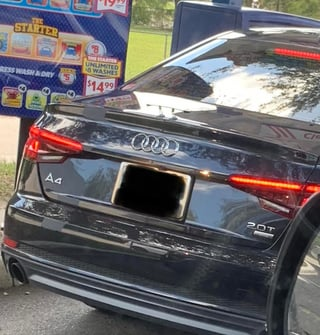

In [7]:
# Test a sample
Image.open(image_df["image_path"].iloc[0])


In [153]:
# Sample N images for testing (around 10-50)
N = 30
sample_df = image_df.sample(N, random_state=42).reset_index(drop=True)
sample_df.head()

,image_path,clean_title,label,image_url,blip2_caption
0,/content/FakeNews/assets/content/fakeddit_imag...,this extremely long fry from arbys,1,https://preview.redd.it/1cbilca4ufi31.jpg?widt...,a person holding a long orange string
1,/content/FakeNews/assets/content/fakeddit_imag...,boise parks and rec to employ the homeless,1,https://external-preview.redd.it/pM-zpj7zb34SW...,a group of people sitting at a table with papers
2,/content/FakeNews/assets/content/fakeddit_imag...,this japanese restaurant has a paper holder fo...,1,https://external-preview.redd.it/enlHPTM-kcVCB...,a wooden chopstick on a table with a cup of tea
3,/content/FakeNews/assets/content/fakeddit_imag...,avengers infinity war,0,https://preview.redd.it/hzvhmtqaa4v01.png?widt...,a colorful windows logo with squares
4,/content/FakeNews/assets/content/fakeddit_imag...,this red sunset,1,https://preview.redd.it/1b6hu7tk4dt31.jpg?widt...,the sun sets behind a beach and trees


In [9]:
# Load visual concepts list
assets_dir = "/content/FakeNews/assets"
with open(os.path.join(assets_dir, "concepts_list.json"), "r") as f:
    concepts_list = json.load(f)

# Load visual concept embeddings
concept_embs = np.load(os.path.join(assets_dir, "concept_embeddings.npy"))
print(f"Loaded {len(concepts_list)} concepts and embedding matrix {concept_embs.shape}")

Loaded 1365 concepts and embedding matrix (1365, 512)


# Models

Lood all the models to be used later.

In [10]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [11]:
# CLIP
clip_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_name)
clip_processor = CLIPProcessor.from_pretrained(clip_name)
clip_model.to(device)
clip_model.eval()
print("\n-----------------------------------------------------")
print("CLIP loaded successfully.")
print("-----------------------------------------------------")

# RoBERTa
roberta_name = "yaoyinnan/roberta-fakeddit"  # pretrained on Fakeddit dataset
roberta_tok = AutoTokenizer.from_pretrained(roberta_name)
roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_name)
roberta_model.to(device)
roberta_model.eval()
print("\n-----------------------------------------------------")
print("RoBERTa loaded successfully.")
print("-----------------------------------------------------")

# SentenceTransformer
sim_model = SentenceTransformer("all-mpnet-base-v2")
sim_model.to(device)
print("\n-----------------------------------------------------")
print("MPNet loaded successfully.")
print("-----------------------------------------------------")

# Sentiment Heuristic (VADER)
vader_analyzer = SentimentIntensityAnalyzer()

print("\n-----------------------------------------------------")
print("All models loaded successfully.")
print("-----------------------------------------------------")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


-----------------------------------------------------
MPNet loaded successfully.
-----------------------------------------------------

-----------------------------------------------------
All models loaded successfully.
-----------------------------------------------------


In [12]:
# Helper to encode image
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# LangChain Tools

Define the LangChain tools and format their outputs.

## Vision Tool

Gather all visual evidence through CLIP.

In [281]:
# Define labels for CLIP prompts
label_prompts = [
    "a staged or manipulated fake news photo",
    "a real photo from a legitimate news report"
]

In [282]:
@tool
def vision_tool(image_path: str) -> dict:
    """
    Analyzes an image file.
    Returns: top visual concepts (CLIP), and Fake/Real classification (CLIP Zero-Shot).
    """
    image = Image.open(image_path).convert("RGB")

    # CLIP features (for concepts and zero-shot)
    inputs = clip_processor(images=image, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        img_emb = clip_model.get_image_features(**inputs)
    img_vec = img_emb.squeeze().cpu().numpy()

    # 1. Top-K Concepts
    k=3
    img_vec_norm = img_vec / norm(img_vec)
    concept_mags = norm(concept_embs, axis=1)
    concept_embs_norm = concept_embs / concept_mags[:, np.newaxis]
    sims = concept_embs_norm @ img_vec_norm
    topk_idx = sims.argsort()[::-1][:k]
    topk = [f"{concepts_list[i]} ({sims[i]:.2f})" for i in topk_idx]

    # 2. CLIP Zero-Shot
    text_inputs = clip_processor(text=label_prompts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_embs = clip_model.get_text_features(**text_inputs)

    # Calculate similarity for ZS (manual dot product)
    text_embs_norm = text_embs / text_embs.norm(dim=1, keepdim=True)
    img_emb_norm = img_emb / img_emb.norm(dim=1, keepdim=True)
    logits = (img_emb_norm @ text_embs_norm.T).squeeze()
    probs = logits.softmax(dim=0).cpu().numpy()

    zs_pred_idx = np.argmax(probs)
    zs_label = "Real" if zs_pred_idx == 1 else "Fake"
    zs_conf = float(probs[zs_pred_idx])

    return {

            "visual_concepts": topk,
            "clip_zs_label": zs_label,
            "clip_zs_confidence": zs_conf
    }


Turn the quantitative evidence into a qualitative summary.

In [283]:
def format_vision_evidence(tool_result: dict) -> str:
    """
    Turn raw vision_tool output into a short, human-readable summary
    for the vision agent to reason about.
    """
    # Extract fields with safe defaults
    label = tool_result.get("clip_zs_label")
    conf  = tool_result.get("clip_zs_confidence")
    concepts = tool_result.get("visual_concepts")

    # Map numeric confidence to a qualitative bucket
    if conf >= 0.8:
        conf_desc = "high"
    elif conf >= 0.5:
        conf_desc = "medium"
    else:
        conf_desc = "low"
    conf_str = f"{conf_desc} confidence (score ≈ {conf:.2f})"

    # Strip scores from concepts and keep only names
    concept_names = [c.split("(")[0].strip() for c in concepts]
    concepts_str = ", ".join(concept_names)

    # Write a summary for the llm agent
    summary_lines = [
        f"- The vision classifier's current guess for this image is: {label} with {conf_str}.",
        f"- The most relevant visual concepts detected are: {concepts_str}.",
    ]

    return "\n".join(summary_lines)


## Text Tool

Gather all textual evidence through RoBERTa and VADER.

In [284]:
@tool
def text_tool(user_text: str) -> dict:
    """
    Analyzes the User Headline and computes VADER sentiment for the headline only.
    Returns: RoBERTa classification and VADER scores for the User Headline.
    """
    results = {}

    # 1. RoBERTa Classification
    inputs = roberta_tok(user_text, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        out = roberta_model(**inputs)
        probs = F.softmax(out.logits, dim=1).squeeze()

    pred_idx = torch.argmax(probs).item()
    label = "Fake" if pred_idx == 0 else "Real"
    conf = float(probs[pred_idx])

    # 2. VADER Sentiment
    sentiment = vader_analyzer.polarity_scores(user_text)["compound"]

    return {
        "roberta_label": label,
        "roberta_conf": conf,
        "vader_sentiment": sentiment
    }


Turn the quantitative evidence into a qualitative summary.

In [285]:
def format_text_evidence(tool_result: dict) -> str:
    """
    Turn raw text_tool output into a short, human-readable summary
    for the text agent to reason about.
    """
    # Extract fields with safe defaults
    label = tool_result.get("roberta_label")
    conf  = tool_result.get("roberta_conf")
    sent  = tool_result.get("vader_sentiment")

    # Map numeric confidence to a qualitative bucket
    if conf >= 0.8:
        conf_desc = "high"
    elif conf >= 0.5:
        conf_desc = "medium"
    else:
        conf_desc = "low"
    conf_str = f"{conf_desc} confidence (score ≈ {conf:.2f})"

    # Map sentiment description from VADER compound score
    if sent >= 0.5:
        sent_label = "positive"
    elif sent <= -0.5:
        sent_label = "negative"
    else:
        sent_label = "neutral"
    sent_str = f"{sent_label} sentiment (compound ≈ {sent:.2f})"

    # Write a summary for the llm agent
    summary_lines = [
        f"- The text classifier's current guess for this headline is: {label} with {conf_str}.",
        f"- The headline's sentiment is: {sent_str}."
    ]

    return "\n".join(summary_lines)


## Context Tool

Gather all multimodal alignment evidence through MPNet and CLIP.

In [286]:
@tool
def context_tool(user_text: str, AI_caption: str, image_path: str) -> dict:
    """
    Computes two-way alignment scores:
    1. Semantic: Text vs Caption
    2. Cross-modal: Image vs Text (User Claim Alignment)
    """
    # 1. Semantic Similarity (MPNet - Text-to-Text)
    emb1 = sim_model.encode(user_text, convert_to_tensor=True, device=device)
    emb2 = sim_model.encode(AI_caption, convert_to_tensor=True, device=device)
    st_sim = util.cos_sim(emb1, emb2).item()

    # 2. Cross-Modal Similarity (CLIP - Image-to-Text)
    image = Image.open(image_path).convert("RGB")

    # Get separate image & text features
    image_inputs = clip_processor(images=image, return_tensors="pt").to(device)
    text_inputs = clip_processor(text=[user_text], return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        img_feats = clip_model.get_image_features(**image_inputs)
        txt_feats = clip_model.get_text_features(**text_inputs)

    # Normalize to unit length
    img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
    txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)

    # Cosine similarity: dot product of normalized vectors
    img_text_sim = float((img_feats @ txt_feats.T).squeeze().item())  # in [-1, 1]

    return {
        "text_to_caption_similarity": st_sim,
        "image_to_text_similarity": img_text_sim
    }


Turn the quantitative evidence into a qualitative summary.

In [287]:
def format_context_evidence(tool_result: dict) -> str:
    """
    Turn raw context tool output into a short, human-readable
    summary for the context agent to reason about.
    """
    # Extract fields with safe defaults
    t2c = tool_result.get("text_to_caption_similarity")
    i2t = tool_result.get("image_to_text_similarity")

    # Map numeric similarity to a qualitative bucket
    def describe_alignment(score: float) -> str:
        """
        Map a cosine similarity score in [-1, 1] to a qualitative label.
        """
        if score >= 0.6:
            desc = "high alignment"
        elif score >= 0.3:
            desc = "medium alignment"
        elif score >= 0.0:
            desc = "weak or generic alignment"
        else:
            desc = "mismatch or contradiction"
        return f"{desc} (score ≈ {score:.2f})"

    text_cap_str = describe_alignment(t2c)
    img_text_str = describe_alignment(i2t)

    # Write a summary for the llm agent
    summary_lines = [
        f"- Semantic alignment between the headline and caption: {text_cap_str}.",
        f"- Cross-modal alignment between the image and headline: {img_text_str}."
    ]

    return "\n".join(summary_lines)


# LangGraph Workflow

In [288]:
# Set LLMs
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.0)
judge_llm = llm
# judge_llm = ChatOpenAI(model="gpt-4.1", temperature=0.0) # smarter model

Define the graph state (Case file)

In [289]:
class AgentState(TypedDict, total=False):
    # Inputs
    image_path: str
    headline: str
    caption: str

    # Forensic agent reports (text, what the Judge reads)
    vision_report: Optional[str]
    text_report: Optional[str]
    context_report: Optional[str]

    # Full JSON from each agent (for later analysis)
    vision_raw: Optional[dict]
    text_raw: Optional[dict]
    context_raw: Optional[dict]

    # Final output
    judge_report: Optional[str]
    judge_raw: Optional[dict]


Define the nodes (Forensics - Local Level)

## Vision Node

In [290]:
def vision_node(state: AgentState) -> AgentState:
    """
    Role: Graphics Forensics Expert
    Input: Image (via Path)
    Phases: 1. Look (as GPT) -> 2. Verify (with CLIP) -> 3. Report (to GPT)
    """
    print("\nVision Agent: Collecting graphical evidence...")

    # Run Tool to gather forensic evidence
    image_path = state["image_path"]
    tool_result = vision_tool.invoke({"image_path": image_path})
    vision_evidence = format_vision_evidence(tool_result)

    # Encode image for the agent
    base64_img = encode_image(image_path)

    # Define the instruction message (system role)
    system_msg = """
    You are a VISION FORENSIC AGENT in a misinformation investigation.

    SCOPE:
    - Your mission is to detect whether the image is likely associated with real, benign news or with fake, manipulated news.
    - Your forensic department provided you with the evidence obtained through a forensic toolkit.
    - You report your findings to the Judge.

    FORENSIC TOOLKIT:
    - Analyzes the user-provided image.
    - Vision Classifier: Flags the image as potentially Fake or Real.
    - Visual Concept Detector: Detects visual concepts or objects in the image.
    - Classifier and detector are separate tools; treat their results as independent signals.

    IMPORTANT:
    - Your final decision should NOT simply repeat your initial impression; it must synthesize the tool's summary.
    - Do NOT assume an image is "Fake" just because it looks illustrated, painted, drawn or designed; a non real-life photo can also be real.
    - Reserve "Fake" for cases where the image itself is misleading or manipulated as evidence.

    PROTOCOL:
    Follow this three-step protocol to write your report:
    1) Intuition: Inspect the image. Give an initial hunch about the news authenticity: Real or Fake, and why.
    2) Forensics: Use the forensic tool results as noisy evidence that may support or challenge your hunch.
    3) Synthesis: Give a final decision about the news authenticity, note if you changed your mind, and set confidence (High/Medium/Low).

    CONFIDENCE FIELD:
    When setting "confidence":
    - Use "High" if forensic evidence clearly supports your decision.
    - Use "Medium" if forensic evidence is mixed but leans toward your decision.
    - Use "Low" if forensic evidence is weak or conflicting and you had to choose despite uncertainty.

    OUTPUT:
    Return a single JSON object with keys:
    {{
      "initial_impression": "Real" or "Fake",
      "initial_reasoning": "Brief summary of your initial impression.",
      "final_decision": "Real" or "Fake",
      "changed_mind": "Yes" or "No",
      "confidence": "High" or "Medium" or "Low",
      "report": "A narrative paragraph (3–5 sentences) for the Judge to read."
    }}
    """.strip()

    # Define the input message (human role - text part)
    human_msg = f"""
    Please analyze the following image and its forensic summary in a misinformation case.

    IMAGE PATH: {image_path}

    FORENSIC SUMMARY: {vision_evidence}

    The actual image is also attached for your direct visual observation.
    """.strip()

    # Build prompt
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_msg),
        ("human", [
            {"type": "text", "text": human_msg},
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_img}"}},
        ]),
    ])

    chain = prompt | llm | JsonOutputParser()
    result = chain.invoke({})  # result is a dict with keys inc. "report"

    # Extract the narrative report for the Judge
    report = result["report"]

    return {
        "vision_report": report,  # what Judge reads
        "vision_raw": result,     # full JSON for analysis
    }

## Text Node

In [291]:
def text_node(state: AgentState) -> AgentState:
    """
    Role: Linguistic Forensics Expert
    Input: Headline (Text)
    Phases: 1. Read (as GPT) -> 2. Verify (with RoBERTa+Vader) -> 3. Report (to GPT)
    """
    print("\nText Agent: Collecting linguistic evidence...")

    # Run Tool to gather forensic evidence
    headline = state["headline"]
    tool_result = text_tool.invoke({"user_text": headline})
    text_evidence = format_text_evidence(tool_result)

    # Define the instruction message (system role)
    system_msg = """
    You are a LINGUISTIC FORENSIC AGENT in a misinformation investigation.

    SCOPE:
    - Your mission is to detect whether the headline is likely associated with real, benign news or with fake, manipulated news.
    - Your forensic department provided you with the evidence obtained through a forensic toolkit.
    - You report your findings to the Judge.

    FORENSIC TOOLKIT:
    - Analyzes the user-provided headline.
    - Flags the headline as potentially Fake or Real using a text classifier.
    - Measures the headline's sentiment (e.g., sensationalism) using a sentiment analyzer.

    IMPORTANT:
    - Your final decision should NOT simply repeat your initial impression; it must synthesize the tool's summary.
    - Do NOT call a headline "Fake" solely because it is emotional, sarcastic, or strongly worded.
    - Reserve "Fake" for the content that is factually fabricated or deceptive.

    PROTOCOL:
    Follow this three-step protocol to write your report:
    1) Intuition: Inspect the headline. Give an initial hunch about the news authenticity: Real or Fake, and why.
    2) Forensics: Use the forensic tool results as noisy evidence that may support or challenge your hunch.
    3) Synthesis: Give a final decision about the news authenticity, note if you changed your mind, and set confidence (High/Medium/Low).

    CONFIDENCE FIELD:
    When setting "confidence":
    - Use "High" if forensic evidence clearly supports your decision.
    - Use "Medium" if forensic evidence is mixed but leans toward your decision.
    - Use "Low" if forensic evidence is weak or conflicting and you had to choose despite uncertainty.

    OUTPUT:
    Return a single JSON object with keys:
    {{
      "initial_impression": "Real" or "Fake",
      "initial_reasoning": "Brief summary of your initial impression.",
      "final_decision": "Real" or "Fake",
      "changed_mind": "Yes" or "No",
      "confidence": "High" or "Medium" or "Low",
      "report": "A narrative paragraph (3–5 sentences) for the Judge to read."
    }}
    """.strip()

    # Define the input message (human role - text part)
    human_msg = f"""
    Please analyze the following headline and its forensic summary in a misinformation case.

    HEADLINE: {headline}

    FORENSIC SUMMARY: {text_evidence}
    """.strip()

    # Build prompt
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_msg),
        ("human", human_msg),
    ])

    chain = prompt | llm | JsonOutputParser()
    result = chain.invoke({})
    report = result["report"]

    return {
        "text_report": report,
        "text_raw": result,
    }

## Context Node

In [292]:
def context_node(state: AgentState) -> AgentState:
    """
    Role: Context Forensics Expert
    Input: Image + Headline + Caption
    Phases: 1. Look and Read (as GPT) -> 2. Verify (with MPNet+CLIP) -> 3. Report (to GPT)
    """
    print("\nContext Agent: Collecting contextual evidence...")

    # Run Tool to gather forensic evidence
    headline = state["headline"]
    caption = state["caption"]
    image_path = state["image_path"]
    tool_result = context_tool.invoke({
        "user_text": headline,
        "AI_caption": caption,
        "image_path": image_path
    })
    context_evidence = format_context_evidence(tool_result)

    # Encode image for the agent
    base64_img = encode_image(state["image_path"])

    # Define the instruction message (system role)
    system_msg = """
    You are a CONTEXT FORENSIC AGENT in a misinformation investigation.

    SCOPE:
    - Your mission is to detect whether the image, headline, caption form a coherent, authentic context or show signs of generic or even contradictory usage.
    - Your forensic department provided you with the evidence obtained through a forensic toolkit.
    - You report your findings to the Judge.

    FORENSIC TOOLKIT:
    - Analyzes the user-provided image and headline, and AI-generated caption of the image together.
    - Measures how well the headline and caption align semantically.
    - Measures cross-modal alignment between the image and headline.

    IMPORTANT:
    - Your final decision should NOT simply repeat your initial impression; it must synthesize the tool's summary.
    - Reserve "Aligned" for when the contents are semantically consistent and there is high or medium cross-modal alignment.
    - Reserve "Generic" for when the contents are only loosely related or stock-like, but not clearly wrong.
    - Reserve "Mismatch" for clear semantic contradictions or strong cross-modal misalignment.

    PROTOCOL:
    Follow this three-step protocol to write your report:
    1) Intuition: Inspect the image, headline, and caption. Give an initial hunch: Aligned or Generic or Mismatch, and why.
    2) Forensics: Use the forensic tool results as noisy evidence that may support or challenge your hunch.
    3) Synthesis: Give a final decision about the context alignment, note if you changed your mind, and set confidence (High/Medium/Low).

    CONFIDENCE FIELD:
    When setting "confidence":
    - Use "High" if forensic evidence clearly supports your decision.
    - Use "Medium" if forensic evidence is mixed but leans toward your decision.
    - Use "Low" if forensic evidence is weak or conflicting and you had to choose despite uncertainty.

    OUTPUT:
    Return a single JSON object with keys:
    {{
      "initial_impression": "Aligned" or "Generic" or "Mismatch",
      "initial_reasoning": "Brief summary of your initial impression.",
      "final_decision": "Aligned" or "Generic" or "Mismatch",
      "changed_mind": "Yes" or "No",
      "confidence": "High" or "Medium" or "Low",
      "report": "A narrative paragraph (3–5 sentences) for the Judge to read."
    }}
    """.strip()

    # Define the input message (human role - text part)
    human_msg = f"""
    Please analyze the following image, headline, caption and their forensic summary in a misinformation case.

    IMAGE PATH: {image_path}
    HEADLINE: {headline}
    CAPTION: {caption}

    FORENSIC SUMMARY: {context_evidence}

    The actual image is also attached for your direct visual observation.
    """.strip()

    # Build prompt
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_msg),
        ("human", [
            {"type": "text", "text": human_msg},
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_img}"}},
        ]),
    ])

    chain = prompt | llm | JsonOutputParser()
    result = chain.invoke({})
    report = result["report"]

    return {
        "context_report": report,
        "context_raw": result,
    }

## Judge Node

Define the master node (Judge - Global Level)

In [293]:
def judge_node(state: AgentState):
    """
    Role: The Judge
    Input: Image + Headline + 3 Reports
    Logic: Intuition -> Forensic Reports -> Verdict
    """
    print("\nJudge Agent: Reading all forensics reports...")

    # Core inputs
    image_path = state["image_path"]
    headline = state["headline"]
    base64_img = encode_image(state["image_path"])

    # Forensic reports from specialist agents
    vision_report = state["vision_report"]
    text_report = state["text_report"]
    context_report = state["context_report"]

    # Confidence of agents
    vision_conf = state["vision_raw"].get("confidence")
    text_conf = state["text_raw"].get("confidence")
    context_conf = state["context_raw"].get("confidence")

    # Define the instruction message (system role)
    system_msg = """
    You are the JUDGE in a multimodal misinformation investigation.

    SCOPE:
    - Your mission is to decide whether a news item (image + headline) is more likely associated with real/benign content or fake/misleading content.
    - You receive forensic reports from three specialist agents, each focusing on a different aspect: visual, linguistic, and contextual authenticity.
    - Integrating these reports, you provide a clear final decision and rationale to a human decision-maker.

    FORENSIC AGENTS:
    - Vision Agent: focuses on image authenticity.
    - Text Agent: focuses on headline realism and linguistic cues.
    - Context Agent: focuses on how well image, headline, and caption align.

    IMPORTANT:
    - Your final decision should NOT simply repeat your initial impression; it must synthesize the agents' expertise.
    - Treat each forensic report as noisy but expert evidence. Agents may disagree because their evidence sources have different strengths and limitations.
    - Use each agent's "confidence" as a proxy for reliability:
      - High confidence = strong, trustworthy evidence.
      - Medium confidence = useful but should be weighed with caution.
      - Low confidence = weak or uncertain evidence; do not let it dominate the decision.
    - When agents disagree:
      - Look at how many agents support Real vs Fake.
      - Give more weight to agents that are both (a) confident and (b) well-aligned with the other reports.
      - If most high-confidence agents agree on one side, you should usually adopt that side, even if your initial impression was different.
      - Generic context is NOT a disagreement and does NOT mean the news is fake; it simply indicates weak alignment, likely due to generic content.
    - When setting your own "confidence":
      - Use "High" if forensic reports clearly and consistently support your decision.
      - Use "Medium" if forensic reports are somewhat mixed but overall lean toward your decision.
      - Use "Low" if forensic reports are weak or conflicting and you had to choose despite uncertainty.

    PROTOCOL:
    Follow this three-step protocol to produce your final decision:
    1) Intuition (Global):
       - First, inspect ONLY the image and headline.
       - Form an initial hunch: "Real" or "Fake", and briefly explain why.
       - In this step, do NOT rely on the forensic reports yet.

    2) Forensics (Read Reports):
       - Carefully read the Vision, Text, and Context reports.
       - Identify where they agree or disagree.
       - Reflect on whether they support or challenge your initial hunch.

    3) Synthesis (Verdict):
       - Decide a final judgment for the news item: "Real" or "Fake".
       - State explicitly whether you changed your mind after reading the reports.
       - Indicate which source of evidence contributed most to your final decision: "Vision Report" or "Text Report" or "Context Report".
       - Set a confidence level (High/Medium/Low) based on the agreement/strength of evidence.
       - Write a short explanation suitable for the public.
       - Give one practical nudge: how a user could think more critically about similar content.

    OUTPUT:
    Return a single JSON object with keys:
    {{
      "initial_impression": "Real" or "Fake",
      "initial_reasoning": "Brief summary of your initial impression.",
      "final_decision": "Real" or "Fake",
      "changed_mind": "Yes" or "No",
      "evidence_source": "Vision Report" or "Text Report" or "Context Report",
      "confidence": "High" or "Medium" or "Low",
      "explanation": "A narrative paragraph (3–5 sentences) to the public. Start with your intuition and explain how the forensic reports confirmed or refuted your initial thought.",
      "nudge": "One actionable piece of advice to the public."
    }}
    """.strip()

    # Define the input message (human role - text part)
    human_msg = f"""
    Please analyze the following news item (image and headline), three forensic reports in a misinformation case and the confidence of each forensic agent.

    NEWS:
    - IMAGE PATH: {image_path}
    - HEADLINE: {headline}

    FORENSIC REPORTS:
    - VISION AGENT REPORT: {vision_report}
    - TEXT AGENT REPORT: {text_report}
    - CONTEXT AGENT REPORT: {context_report}

    AGENT CONFIDENCE:
    - VISION AGENT: {vision_conf}
    - TEXT AGENT: {text_conf}
    - CONTEXT AGENT: {context_conf}

    The actual image is also attached for your direct visual observation.
    """.strip()

    # Build prompt
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_msg),
        ("human", [
            {"type": "text", "text": human_msg},
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_img}"}},
        ]),
    ])

    # Generate Output
    chain = prompt | judge_llm | JsonOutputParser()
    result = chain.invoke({})
    report = result["explanation"]

    return {
        "judge_report": report,
        "judge_raw": result,
    }

## Compiler

Compile the graph (Architecture)

In [294]:
# Set compiler
workflow = StateGraph(AgentState)

# Add Nodes
workflow.add_node("vision_agent", vision_node)
workflow.add_node("text_agent", text_node)
workflow.add_node("context_agent", context_node)
workflow.add_node("judge_agent", judge_node)

# Add Edges (Sequential Execution) START -> Vision -> Text -> Alignment -> Supervisor -> END
workflow.set_entry_point("vision_agent") # Or a "Router" node if you want true parallel start
workflow.add_edge("vision_agent", "text_agent") # Sequential for simplicity in v1
workflow.add_edge("text_agent", "context_agent")
workflow.add_edge("context_agent", "judge_agent")
workflow.add_edge("judge_agent", END)

# Compile
app = workflow.compile()


# Debug


Vision Agent: Collecting graphical evidence...

Text Agent: Collecting linguistic evidence...

Context Agent: Collecting contextual evidence...

Judge Agent: Reading all forensics reports...

=== IMAGE PATH ===
/content/FakeNews/assets/content/fakeddit_images/4.jpg


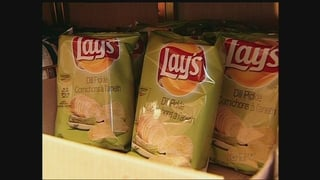


=== HEADLINE ===
chips and salsa worth stolen from exeter storage unit

=== TRUE LABEL ===
real

=== CAPTION ===
lays chips are in a display case

=== VISION AGENT REPORT ===
Upon inspection, the image depicts Lay's chips with an unusual flavor label 'Dip de Camarones,' which is not a common or known Lay's flavor, suggesting possible manipulation or fake packaging. The forensic vision classifier leans slightly towards the image being real but with only medium confidence, and the detected concepts like 'guacamole' and 'packet' do not strongly confirm authenticity. Given the suspicious flavor labeling and lack of strong forensic support for authenticity, the image is likely fake or misleading, with medium confidence.

=== TEXT AGENT REPORT ===
The headline reports a straightforward theft of chips and salsa from a storage unit in Exeter, which is a plausible and non-sensational news item. The forensic toolkit strongly supports this impression, classifying the headline as real with high c

In [295]:
# Run a sample
sample = image_df.iloc[4]
initial_state = {
    "image_path": sample["image_path"],
    "headline": sample["clean_title"],
    "caption": sample["blip2_caption"],
}

result_state = app.invoke(initial_state)

print("\n=== IMAGE PATH ===")
print(sample["image_path"])

display(Image.open(sample["image_path"]))

print("\n=== HEADLINE ===")
print(sample["clean_title"])

print("\n=== TRUE LABEL ===")
print(f"real" if sample["label"] == 1 else "fake")

print("\n=== CAPTION ===")
print(sample["blip2_caption"])

print("\n=== VISION AGENT REPORT ===")
print(result_state.get("vision_report"))

print("\n=== TEXT AGENT REPORT ===")
print(result_state.get("text_report"))

print("\n=== CONTEXT AGENT REPORT ===")
print(result_state.get("context_report"))

print("\n=== JUDGE VERDICT ===")
judge = result_state.get("judge_raw", {})
print("Initial impression:", judge.get("initial_impression"))
print("Final decision    :", judge.get("final_decision"))
print("Changed mind?     :", judge.get("changed_mind"))
print("Evidence source   :", judge.get("evidence_source"))
print("Confidence        :", judge.get("confidence"))

print("\n=== JUDGE EXPLANATION ===")
print(judge.get("explanation", ""))

print("\n=== JUDGE NUDGE ===")
print(judge.get("nudge", ""))


# Pipeline

In [301]:
# Run pipeline
results = []

for i, row in tqdm(image_df.iterrows(), total=len(image_df)): # use sample_df for N samples
    state_in = {
        "image_path": row["image_path"],
        "headline": row["clean_title"],
        "caption": row["blip2_caption"],
    }

    try:
        out_state = app.invoke(state_in)

        # Get vision, text, judge agent results
        v_raw = out_state.get("vision_raw")
        t_raw = out_state.get("text_raw")
        c_raw = out_state.get("context_raw")
        j_raw = out_state.get("judge_raw")

        results.append({
            # metadata
            "image_path": row["image_path"],
            "headline":   row["clean_title"],
            "caption":    row["blip2_caption"],
            "true_label": row["label"],

            # vision agent
            "vision_initial":    v_raw.get("initial_impression"),
            "vision_ireasoning": v_raw.get("initial_reasoning"),
            "vision_final":      v_raw.get("final_decision"),
            "vision_changed":    v_raw.get("changed_mind"),
            "vision_conf":       v_raw.get("confidence"),
            "vision_report":     v_raw.get("report"),

            # text agent
            "text_initial":    t_raw.get("initial_impression"),
            "text_ireasoning": t_raw.get("initial_reasoning"),
            "text_final":      t_raw.get("final_decision"),
            "text_changed":    t_raw.get("changed_mind"),
            "text_conf":       t_raw.get("confidence"),
            "text_report":     t_raw.get("report"),

            # context agent
            "context_initial":    c_raw.get("initial_impression"),
            "context_ireasoning": c_raw.get("initial_reasoning"),
            "context_final":      c_raw.get("final_decision"),
            "context_changed":    c_raw.get("changed_mind"),
            "context_conf":       c_raw.get("confidence"),
            "context_report":     c_raw.get("report"),

            # judge agent
            "judge_initial":    j_raw.get("initial_impression"),
            "judge_ireasoning": j_raw.get("initial_reasoning"),
            "judge_final":      j_raw.get("final_decision"),
            "judge_changed":    j_raw.get("changed_mind"),
            "evidence_source":  j_raw.get("evidence_source"),
            "judge_conf":       j_raw.get("confidence"),
            "judge_report":     j_raw.get("explanation"),
            "judge_nudge":      j_raw.get("nudge"),

            # full json for debugging
            "vision_json":   json.dumps(v_raw),
            "text_json":     json.dumps(t_raw),
            "context_json":  json.dumps(c_raw),
            "judge_json":    json.dumps(j_raw),
        })

    except Exception as e:
        print(f"Error on row {i}: {e}")
        results.append({
            "idx": i,
            "image_path": row["image_path"],
            "headline":   row["clean_title"],
            "caption":    row["blip2_caption"],
            "true_label": row["label"],
            "error": str(e),
        })

# Save results
results_df = pd.DataFrame(results)
print("\nProcessing Complete.")
results_df.head()

  0%|          | 0/225 [00:00<?, ?it/s]


Vision Agent: Collecting graphical evidence...

Text Agent: Collecting linguistic evidence...

Context Agent: Collecting contextual evidence...

Judge Agent: Reading all forensics reports...


  0%|          | 1/225 [00:16<1:02:56, 16.86s/it]


Vision Agent: Collecting graphical evidence...

Text Agent: Collecting linguistic evidence...

Context Agent: Collecting contextual evidence...

Judge Agent: Reading all forensics reports...


  1%|          | 2/225 [00:31<57:47, 15.55s/it]  

...

100%|█████████▉| 224/225 [52:53<00:14, 14.10s/it]


Vision Agent: Collecting graphical evidence...

Text Agent: Collecting linguistic evidence...

Context Agent: Collecting contextual evidence...

Judge Agent: Reading all forensics reports...


100%|██████████| 225/225 [53:05<00:00, 14.16s/it]


Processing Complete.


,image_path,headline,caption,true_label,vision_initial,vision_ireasoning,vision_final,vision_changed,vision_conf,vision_report,...,judge_final,judge_changed,evidence_source,judge_conf,judge_report,judge_nudge,vision_json,text_json,context_json,judge_json
0,/content/FakeNews/assets/content/fakeddit_imag...,this tiny spoiler on this car,the back end of a black audi parked at a gas s...,1,Fake,"The car in the image is clearly an Audi A4, bu...",Fake,No,Medium,"Upon visual inspection, the car is an Audi A4,...",...,Real,No,Text Report,Medium,"Initially, the image and headline appeared gen...",When encountering simple descriptive headlines...,"{""initial_impression"": ""Fake"", ""initial_reason...","{""initial_impression"": ""Real"", ""initial_reason...","{""initial_impression"": ""Generic"", ""initial_rea...","{""initial_impression"": ""Real"", ""initial_reason..."
1,/content/FakeNews/assets/content/fakeddit_imag...,i am going to a hospital in due to notoriety o...,a man in white clothes is surrounded by police...,0,Real,The image shows a person in a white protective...,Real,No,Medium,"The image depicts a person in custody, wearing...",...,Fake,No,Text Report,High,My initial impression was that the news item i...,When encountering confusing or poorly written ...,"{""initial_impression"": ""Real"", ""initial_reason...","{""initial_impression"": ""Fake"", ""initial_reason...","{""initial_impression"": ""Generic"", ""initial_rea...","{""initial_impression"": ""Fake"", ""initial_reason..."
2,/content/FakeNews/assets/content/fakeddit_imag...,flamingo bros where are my shoes,a woman sitting in a chair with the words flam...,0,Fake,The image appears to be a digitally created or...,Fake,No,Medium,"Upon inspection, the image looks more like a d...",...,Fake,No,Text Report,High,My initial impression was that this news item ...,When encountering unusual or nonsensical headl...,"{""initial_impression"": ""Fake"", ""initial_reason...","{""initial_impression"": ""Fake"", ""initial_reason...","{""initial_impression"": ""Generic"", ""initial_rea...","{""initial_impression"": ""Fake"", ""initial_reason..."
3,/content/FakeNews/assets/content/fakeddit_imag...,people really did buy poop on black friday,a brown box with a black face on it,1,Real,The image shows a simple cardboard box with a ...,Real,No,Medium,The image depicts a cardboard box with a smili...,...,Real,No,Text Report,High,My initial impression was that this news item ...,"When encountering unusual headlines, consider ...","{""initial_impression"": ""Real"", ""initial_reason...","{""initial_impression"": ""Real"", ""initial_reason...","{""initial_impression"": ""Generic"", ""initial_rea...","{""initial_impression"": ""Real"", ""initial_reason..."
4,/content/FakeNews/assets/content/fakeddit_imag...,chips and salsa worth stolen from exeter stora...,lays chips are in a display case,1,Real,The image shows a shelf with Lay's chips bags ...,Real,No,Medium,The image depicts Lay's chips bags on a store ...,...,Real,No,Text Report,High,My initial impression was that the news item i...,"When encountering news about minor incidents, ...","{""initial_impression"": ""Real"", ""initial_reason...","{""initial_impression"": ""Real"", ""initial_reason...","{""initial_impression"": ""Generic"", ""initial_rea...","{""initial_impression"": ""Real"", ""initial_reason..."


In [302]:
# Check how often they actually swapped
vision_swaps = np.sum(results_df["vision_initial"] != results_df["vision_final"])
text_swaps   = np.sum(results_df["text_initial"] != results_df["text_final"])
context_swaps = np.sum(results_df["context_initial"] != results_df["context_final"])
judge_swaps  = np.sum(results_df["judge_initial"] != results_df["judge_final"])

print(f"Vision Agent decision change rate  : {vision_swaps} out of {len(results_df["vision_initial"])} times")
print(f"Text Agent decision change rate    : {text_swaps} out of {len(results_df["text_initial"])} times")
print(f"Context Agent decision change rate : {context_swaps} out of {len(results_df["context_initial"])} times")
print(f"Judge Agent decision change rate   : {judge_swaps} out of {len(results_df["judge_initial"])} times")

Vision Agent decision change rate  : 2 out of 225 times
Text Agent decision change rate    : 21 out of 225 times
Context Agent decision change rate : 0 out of 225 times
Judge Agent decision change rate   : 16 out of 225 times


In [303]:
# Check how confident they were
print(f"\n>>> Vision Agent Confidence:  \n{results_df['vision_conf'].value_counts()}")
print(f"\n>>> Text Agent Confidence:    \n{results_df['text_conf'].value_counts()}")
print(f"\n>>> Context Agent Confidence: \n{results_df['context_conf'].value_counts()}")
print(f"\n>>> Judge Agent Confidence:   \n{results_df['judge_conf'].value_counts()}")


>>> Vision Agent Confidence:  
vision_conf
Medium    194
High       31
Name: count, dtype: int64

>>> Text Agent Confidence:    
text_conf
High      192
Medium     33
Name: count, dtype: int64

>>> Context Agent Confidence: 
context_conf
High      128
Medium     97
Name: count, dtype: int64

>>> Judge Agent Confidence:   
judge_conf
High      152
Medium     73
Name: count, dtype: int64


In [304]:
# Review a sample
results_df.iloc[4]

,4
image_path,/content/FakeNews/assets/content/fakeddit_imag...
headline,chips and salsa worth stolen from exeter stora...
caption,lays chips are in a display case
true_label,1
vision_initial,Real
vision_ireasoning,The image shows a shelf with Lay's chips bags ...
vision_final,Real
vision_changed,No
vision_conf,Medium
vision_report,The image depicts Lay's chips bags on a store ...


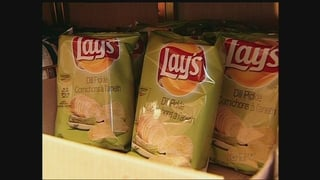

In [305]:
# Image
Image.open(results_df.image_path[4])

In [306]:
# Vision agent's report
results_df.vision_report[4]

"The image depicts Lay's chips bags on a store shelf, which look authentic and typical for retail packaging. The forensic summary supports this by classifying the image as Real with medium confidence and detecting relevant visual concepts like 'packet' and 'carton' that align with the product shown. There are no obvious signs of manipulation or misleading content in the image. Therefore, the image is likely associated with real, benign news."

In [307]:
# Vision agent's results
print("\n=== VISION VERDICT ===")
judge = result_state.get("judge_raw", {})
print("Initial impression :", results_df.vision_initial[4])
print("Final decision     :", results_df.vision_final[4])
print("Changed mind?      :", results_df.vision_changed[4])
print("Confidence         :", results_df.vision_conf[4])


=== VISION VERDICT ===
Initial impression : Real
Final decision     : Real
Changed mind?      : No
Confidence         : Medium


In [308]:
# Text agent's report
results_df.text_report[4]

'The headline appears to report a straightforward incident of theft involving chips and salsa from a storage unit in Exeter. The forensic toolkit strongly supports this impression, classifying the headline as real with high confidence and detecting a neutral sentiment, which aligns with the non-sensational nature of the headline. There is no indication of fabrication or manipulation in the content, so the final decision is that the news is real with high confidence.'

In [309]:
# Text agent's results
print("\n=== TEXT VERDICT ===")
judge = result_state.get("judge_raw", {})
print("Initial impression :", results_df.text_initial[4])
print("Final decision     :", results_df.text_final[4])
print("Changed mind?      :", results_df.text_changed[4])
print("Confidence         :", results_df.text_conf[4])


=== TEXT VERDICT ===
Initial impression : Real
Final decision     : Real
Changed mind?      : No
Confidence         : High


In [310]:
# Context agent's report
results_df.context_report[4]

"The image depicts bags of Lay's chips on a shelf, which corresponds generally to the headline about chips being stolen but lacks any direct evidence or context of theft or salsa. The caption correctly describes the chips being in a display case but does not add meaningful context to confirm the headline's claim. The forensic summary shows medium semantic and cross-modal alignment, supporting the idea that the elements are related but not strongly connected. Overall, the content is generic and does not provide a coherent or specific narrative linking the image, headline, and caption."

In [311]:
# Context agent's results
print("\n=== CONTEXT VERDICT ===")
judge = result_state.get("judge_raw", {})
print("Initial impression :", results_df.context_initial[4])
print("Final decision     :", results_df.context_final[4])
print("Changed mind?      :", results_df.context_changed[4])
print("Confidence         :", results_df.context_conf[4])


=== CONTEXT VERDICT ===
Initial impression : Generic
Final decision     : Generic
Changed mind?      : No
Confidence         : High


In [312]:
# Judge's report
results_df.judge_report[4]

"My initial impression was that the news item is real because the image and headline align in a plausible way, showing authentic chips and describing a theft incident involving chips and salsa. The forensic reports confirmed this: the Vision Agent found the image authentic with no manipulation, the Text Agent strongly supported the headline's realism with high confidence, and the Context Agent noted a general but not strong alignment, which is reasonable given the generic nature of the image. Overall, the evidence supports the news being real, though the image alone does not prove the theft, the headline and text evidence are convincing."

In [313]:
# Judge's results
print("\n=== JUDGE VERDICT ===")
judge = result_state.get("judge_raw", {})
print("Initial impression :", results_df.judge_initial[4])
print("Final decision     :", results_df.judge_final[4])
print("Changed mind?      :", results_df.judge_changed[4])
print("Evidence source    :", results_df.evidence_source[4])
print("Confidence         :", results_df.judge_conf[4])


=== JUDGE VERDICT ===
Initial impression : Real
Final decision     : Real
Changed mind?      : No
Evidence source    : Text Report
Confidence         : High


In [314]:
# Judge's advice
results_df.judge_nudge[4]

'When encountering news about minor incidents, consider whether the image directly supports the claim or is just a generic illustration; check for additional context or sources to confirm the story.'

In [315]:
# Check which source of evidence contributed most to judge's final decision
results_df.value_counts("evidence_source")

,count
evidence_source,
Text Report,149
Context Report,41
Vision Report,35


# Evaluation

Compare pre vs. post performance for Vision, Text, and Judge agents.

In [316]:
# Convert textual labels to ints
def label_to_int(x):
    if str(x).lower() == "fake":  return 0
    if str(x).lower() == "real":  return 1
    return None  # for errors / missing / unexpected values

# Make a new df for evaluation
eval_df = pd.DataFrame({
    "true_label": results_df["true_label"].astype(int),
    "va_pre":  results_df["vision_initial"].apply(label_to_int),
    "va_post": results_df["vision_final"].apply(label_to_int),
    "ta_pre":  results_df["text_initial"].apply(label_to_int),
    "ta_post": results_df["text_final"].apply(label_to_int),
    "ja_pre":  results_df["judge_initial"].apply(label_to_int),
    "ja_post": results_df["judge_final"].apply(label_to_int),
})


In [317]:
# Accuracies
va1_acc = np.mean(eval_df["va_pre"]  == eval_df["true_label"])
va2_acc = np.mean(eval_df["va_post"] == eval_df["true_label"])
ta1_acc = np.mean(eval_df["ta_pre"]  == eval_df["true_label"])
ta2_acc = np.mean(eval_df["ta_post"] == eval_df["true_label"])
ja1_acc = np.mean(eval_df["ja_pre"]  == eval_df["true_label"])
ja2_acc = np.mean(eval_df["ja_post"] == eval_df["true_label"])

print("Vision Agent (pre)  accuracy:", round(va1_acc, 3))
print("Vision Agent (post) accuracy:", round(va2_acc, 3))
print("Text Agent   (pre)  accuracy:", round(ta1_acc, 3))
print("Text Agent   (post) accuracy:", round(ta2_acc, 3))
print("Judge Agent  (pre)  accuracy:", round(ja1_acc, 3))
print("Judge Agent  (post) accuracy:", round(ja2_acc, 3))


Vision Agent (pre)  accuracy: 0.68
Vision Agent (post) accuracy: 0.68
Text Agent   (pre)  accuracy: 0.84
Text Agent   (post) accuracy: 0.889
Judge Agent  (pre)  accuracy: 0.698
Judge Agent  (post) accuracy: 0.751


In [318]:
# Confusion matrices

va1_cm = confusion_matrix(eval_df["true_label"], eval_df["va_pre"])
va2_cm = confusion_matrix(eval_df["true_label"], eval_df["va_post"])
ta1_cm = confusion_matrix(eval_df["true_label"], eval_df["ta_pre"])
ta2_cm = confusion_matrix(eval_df["true_label"], eval_df["ta_post"])
ja1_cm = confusion_matrix(eval_df["true_label"], eval_df["ja_pre"])
ja2_cm = confusion_matrix(eval_df["true_label"], eval_df["ja_post"])

print("\nVision Agent (pre) Confusion Matrix:\n", va1_cm)
print("\nVision Agent (post) Confusion Matrix:\n", va2_cm)
print("\nText Agent (pre) Confusion Matrix:\n", ta1_cm)
print("\nText Agent (post) Confusion Matrix:\n", ta2_cm)
print("\nJudge Agent (pre) Confusion Matrix:\n", ja1_cm)
print("\nJudge Agent (post) Confusion Matrix:\n", ja2_cm)



Vision Agent (pre) Confusion Matrix:
 [[ 36  39]
 [ 33 117]]

Vision Agent (post) Confusion Matrix:
 [[ 37  38]
 [ 34 116]]

Text Agent (pre) Confusion Matrix:
 [[ 54  21]
 [ 15 135]]

Text Agent (post) Confusion Matrix:
 [[ 68   7]
 [ 18 132]]

Judge Agent (pre) Confusion Matrix:
 [[ 53  22]
 [ 46 104]]

Judge Agent (post) Confusion Matrix:
 [[ 65  10]
 [ 46 104]]


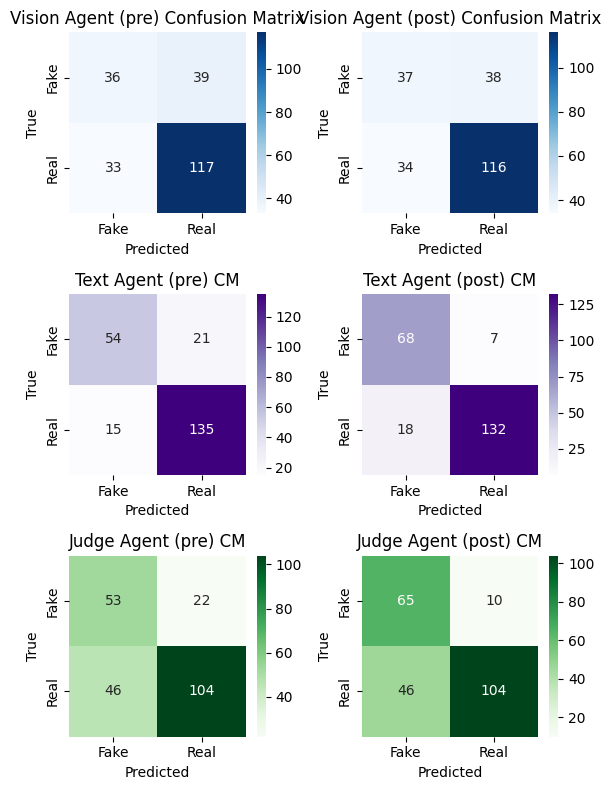

In [319]:
# Heatmaps
fig, axes = plt.subplots(3, 2, figsize=(6, 8))
axes = axes.ravel()  # flatten to 1D: axes[0]..axes[3]

# Vision Agent Pre-Post
sns.heatmap(va1_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            ax=axes[0])
axes[0].set_title("Vision Agent (pre) Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(va2_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            ax=axes[1])
axes[1].set_title("Vision Agent (post) Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

# Text Agent Pre-Post
sns.heatmap(ta1_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            ax=axes[2])
axes[2].set_title("Text Agent (pre) CM")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

sns.heatmap(ta2_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            ax=axes[3])
axes[3].set_title("Text Agent (post) CM")
axes[3].set_xlabel("Predicted")
axes[3].set_ylabel("True")

# Judge Agent Pre-Post
sns.heatmap(ja1_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            ax=axes[4])
axes[4].set_title("Judge Agent (pre) CM")
axes[4].set_xlabel("Predicted")
axes[4].set_ylabel("True")

sns.heatmap(ja2_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            ax=axes[5])
axes[5].set_title("Judge Agent (post) CM")
axes[5].set_xlabel("Predicted")
axes[5].set_ylabel("True")

plt.tight_layout()
plt.show()

In [320]:
# Classification reports
print("\n-----------------------------------------------------")
print("Vision Agent (pre) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["va_pre"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("Vision Agent (post) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["va_post"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("Text Agent (pre) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["ta_pre"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("Text Agent (post) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["ta_post"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("Judge Agent (pre) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["ja_pre"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("Judge Agent (post) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    eval_df["true_label"],
    eval_df["ja_post"],
    target_names=["Fake", "Real"]
))


-----------------------------------------------------
Vision Agent (pre) Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.52      0.48      0.50        75
        Real       0.75      0.78      0.76       150

    accuracy                           0.68       225
   macro avg       0.64      0.63      0.63       225
weighted avg       0.67      0.68      0.68       225


-----------------------------------------------------
Vision Agent (post) Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.52      0.49      0.51        75
        Real       0.75      0.77      0.76       150

    accuracy                           0.68       225
   macro avg       0.64      0.63      0.64       225
weighted avg       0.68      0.68      0.68       225


------------------------------------------

# Observations

**Per-agent**

- **Vision Agent** reaches about **68% accuracy** both before and after consulting its tools.  
  - *Pre-fuse:* fake precision ≈ 0.52, fake recall ≈ 0.48; real precision ≈ 0.75, real recall ≈ 0.78.  
  - *Post-fuse:* the numbers barely move (fake recall nudges up to about 0.49, real precision/recall stay around 0.75/0.77).  
  This suggests the vision toolkit (CLIP zero-shot + visual concepts) provides only **weak, noisy evidence**: the agent’s initial “gut feeling” from the image already captures most of the visual signal, and the tools rarely overturn that impression in a systematic way. The agent remains slightly biased toward predicting *real* for ambiguous cases.

- **Text Agent** is again the **strongest single expert**, and benefits clearly from its forensic tools.  
  - *Pre-fuse:* about **83.1% accuracy**, with fake precision ≈ 0.78, fake recall ≈ 0.72; real precision ≈ 0.87, real recall ≈ 0.90.  
  - *Post-fuse:* accuracy rises to about **88.9%**. Fake recall jumps to roughly **0.91** (it catches many more fake headlines), fake precision stays similar, and real precision increases to about **0.95** at only a small cost in real recall (drops slightly from ≈0.90 to ≈0.88).  
  Using the Fakeddit-trained RoBERTa as the text backbone pays off: the **headline alone remains the most informative modality**, and the text agent’s tools genuinely sharpen its decisions rather than destabilizing them.

- **Judge Agent** starts from a moderate intuition and becomes **meaningfully better after reading the reports**.  
  - *Pre-fuse:* the judge’s initial impression (looking at image + headline, without agents) reaches about **69.8% accuracy**, with a clear tendency to over-flag fake: fake recall ≈ 0.71 but fake precision ≈ 0.54, while real precision ≈ 0.83 and real recall ≈ 0.69.  
  - *Post-fuse:* after integrating the three forensic reports, the judge climbs to about **75.1% accuracy**. Fake recall increases further (≈0.87), and real precision becomes very high (≈0.91), though real recall remains around 0.69.  
  In contrast to the **single-agent blind pipeline**, where adding multimodal tools actually degraded performance, the multi-agent setup makes fusion **constructive**: the judge now uses the agents as genuine experts and often adjusts its verdict, especially when the text agent is confident and vision/context either agree or are neutral.

**Overall**

- The **text channel** is still the dominant source of veracity signal on this Fakeddit subset, but the multi-agent architecture changes how fusion behaves:
  - The **Vision Agent** contributes a useful but relatively weak signal.
  - The **Text Agent** provides a strong, calibrated opinion.
  - The **Context Agent** (via its reports) helps the judge reason about *alignment* rather than directly about truth, which is useful when image and headline point in different directions.

- The **Judge’s final accuracy (~75%)** sits between:
  - the **blind, single-agent fused LLM** (where fusion dragged accuracy down to around 61%), and  
  - the **vision-enabled single-agent fusion pipeline** (which reached about 79% on the same split).  
  This shows that:
  1. **Decomposing** the task into specialized forensic agents and a supervising judge makes fusion *less brittle* than in the blind single-agent setting, and  
  2. There is still some headroom to close the gap with the best single-agent fusion by further improving how the judge arbitrates conflicts (especially when a very strong text signal clashes with weaker visual/contextual cues).

In short, the multi-agent pipeline behaves more like a **panel of experts**: the Vision and Context agents provide nuanced but noisy opinions, the Text agent is a strong anchor, and the Judge learns to rely more on the agents than on its own initial hunch—leading to a more stable and interpretable fusion than in the earlier single-agent blind setup.
